In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r'C:\Infoct_project 1 sample practice\predictive_maintenance.csv')

In [3]:
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


In [4]:
print(df.shape)

(10000, 10)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB
None


In [6]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [7]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='str')


In [8]:
print(df["Target"].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64


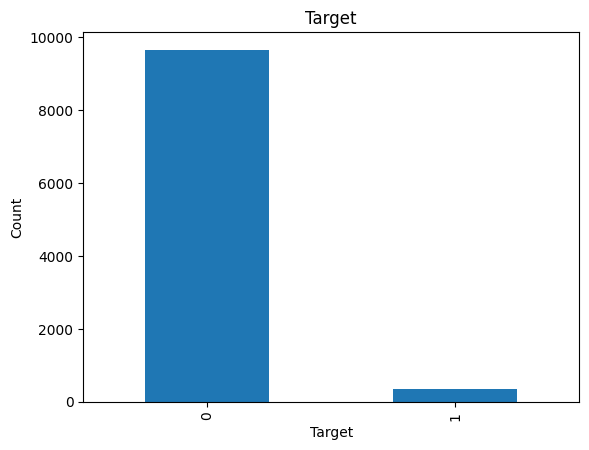

In [9]:
df["Target"].value_counts().plot(kind="bar")
plt.title("Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

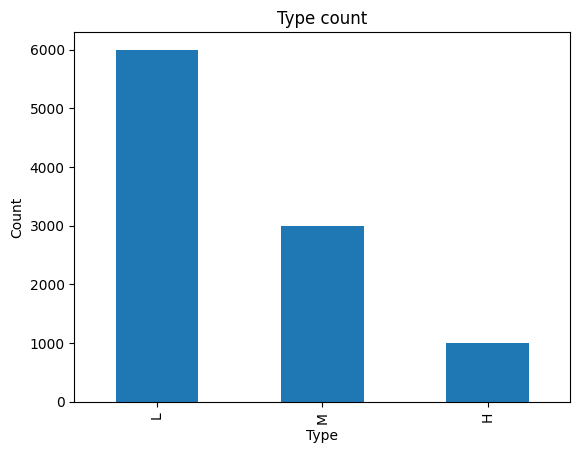

In [10]:
df["Type"].value_counts().plot(kind="bar")
plt.title("Type count")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

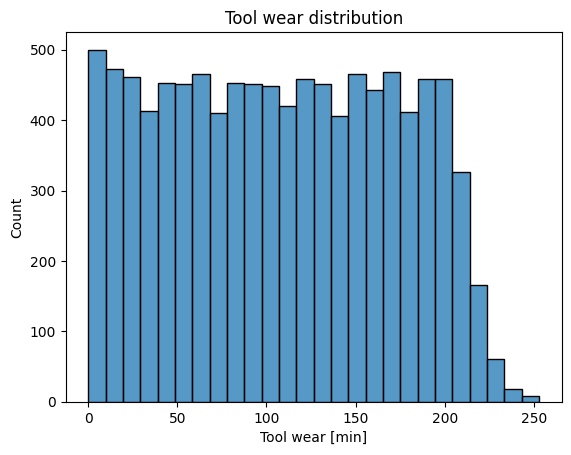

In [11]:
sns.histplot(data=df,x="Tool wear [min]")
plt.title("Tool wear distribution")
plt.show()

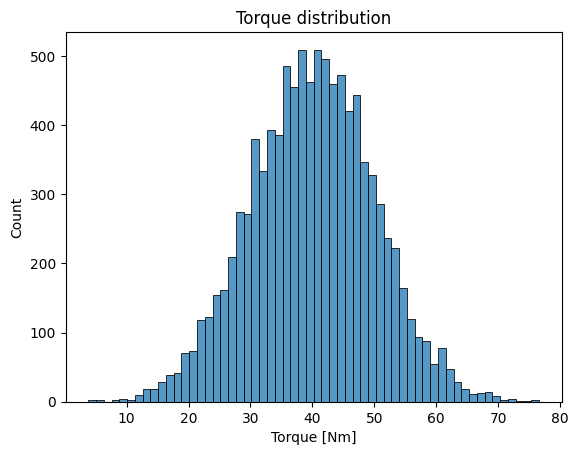

In [12]:
sns.histplot(data=df,x="Torque [Nm]")
plt.title("Torque distribution")
plt.show()

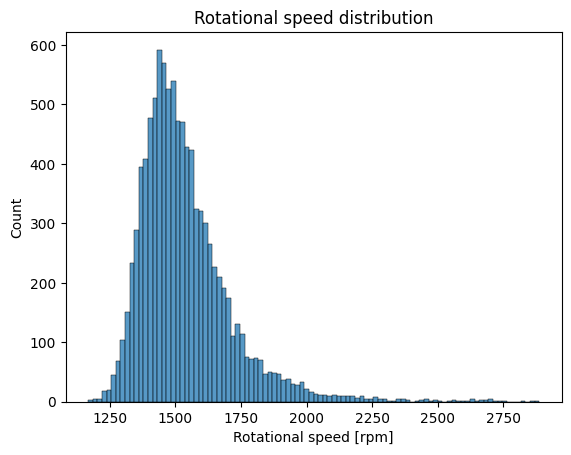

In [13]:
sns.histplot(data=df,x="Rotational speed [rpm]")
plt.title("Rotational speed distribution")
plt.show()

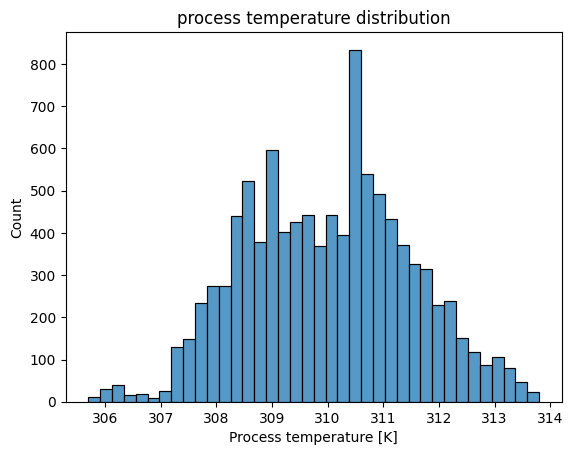

In [14]:
sns.histplot(data=df,x="Process temperature [K]")
plt.title("process temperature distribution")
plt.show()

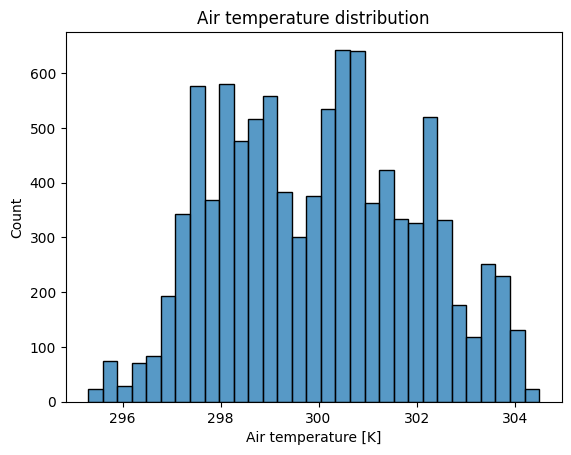

In [15]:
sns.histplot(data=df,x="Air temperature [K]")
plt.title("Air temperature distribution")
plt.show()

In [16]:
df["Air_temperature_rolling_mean"] = df["Air temperature [K]"].rolling(window=5).mean()
df["Air_temperature_rolling_std"] = df["Air temperature [K]"].rolling(window=5).std()
df["Air_temperature_rolling_var"] = df["Air temperature [K]"].rolling(window=5).var()
print(df[["Air temperature [K]", "Air_temperature_rolling_mean", "Air_temperature_rolling_std", "Air_temperature_rolling_var"]].head())

   Air temperature [K]  Air_temperature_rolling_mean  \
0                298.1                           NaN   
1                298.2                           NaN   
2                298.1                           NaN   
3                298.2                           NaN   
4                298.2                        298.16   

   Air_temperature_rolling_std  Air_temperature_rolling_var  
0                          NaN                          NaN  
1                          NaN                          NaN  
2                          NaN                          NaN  
3                          NaN                          NaN  
4                     0.054772                        0.003  


In [17]:
df["Process_temperature_rolling_mean"] = df["Process temperature [K]"].rolling(window=5).mean()
df["Process_temperature_rolling_std"] = df["Process temperature [K]"].rolling(window=5).std()
df["Process_temperature_rolling_var"] = df["Process temperature [K]"].rolling(window=5).var()
print(df[["Process temperature [K]", "Process_temperature_rolling_mean", "Process_temperature_rolling_std", "Process_temperature_rolling_var"]].head())

   Process temperature [K]  Process_temperature_rolling_mean  \
0                    308.6                               NaN   
1                    308.7                               NaN   
2                    308.5                               NaN   
3                    308.6                               NaN   
4                    308.7                            308.62   

   Process_temperature_rolling_std  Process_temperature_rolling_var  
0                              NaN                              NaN  
1                              NaN                              NaN  
2                              NaN                              NaN  
3                              NaN                              NaN  
4                         0.083666                            0.007  


In [18]:
df["Rotational_speed_rolling_mean"] = df["Rotational speed [rpm]"].rolling(window=5).mean()
df["Rotational_speed_rolling_std"] = df["Rotational speed [rpm]"].rolling(window=5).std()
df["Rotational_speed_rolling_var"] = df["Rotational speed [rpm]"].rolling(window=5).var()
print(df[["Rotational speed [rpm]", "Rotational_speed_rolling_mean", "Rotational_speed_rolling_std", "Rotational_speed_rolling_var"]].head())

   Rotational speed [rpm]  Rotational_speed_rolling_mean  \
0                    1551                            NaN   
1                    1408                            NaN   
2                    1498                            NaN   
3                    1433                            NaN   
4                    1408                         1459.6   

   Rotational_speed_rolling_std  Rotational_speed_rolling_var  
0                           NaN                           NaN  
1                           NaN                           NaN  
2                           NaN                           NaN  
3                           NaN                           NaN  
4                     62.970628                        3965.3  


In [19]:
df["Torque_rolling_mean"] = df["Torque [Nm]"].rolling(window=5).mean()
df["Torque_rolling_std"] = df["Torque [Nm]"].rolling(window=5).std()
df["Torque_rolling_var"] = df["Torque [Nm]"].rolling(window=5).var()
print(df[["Torque [Nm]", "Torque_rolling_mean", "Torque_rolling_std", "Torque_rolling_var"]].head())

   Torque [Nm]  Torque_rolling_mean  Torque_rolling_std  Torque_rolling_var
0         42.8                  NaN                 NaN                 NaN
1         46.3                  NaN                 NaN                 NaN
2         49.4                  NaN                 NaN                 NaN
3         39.5                  NaN                 NaN                 NaN
4         40.0                 43.6             4.22315              17.835


In [20]:
df["Tool_wear_rolling_mean"] = df["Tool wear [min]"].rolling(window=5).mean()
df["Tool_wear_rolling_std"] = df["Tool wear [min]"].rolling(window=5).std()
df["Tool_wear_rolling_var"] = df["Tool wear [min]"].rolling(window=5).var()
print(df[["Tool wear [min]", "Tool_wear_rolling_mean", "Tool_wear_rolling_std", "Tool_wear_rolling_var"]].head())

   Tool wear [min]  Tool_wear_rolling_mean  Tool_wear_rolling_std  \
0                0                     NaN                    NaN   
1                3                     NaN                    NaN   
2                5                     NaN                    NaN   
3                7                     NaN                    NaN   
4                9                     4.8                3.49285   

   Tool_wear_rolling_var  
0                    NaN  
1                    NaN  
2                    NaN  
3                    NaN  
4                   12.2  


In [21]:
df=df.dropna()
print(df.shape)

(9996, 25)


In [22]:
X=df.drop(columns=["Product ID","UDI","Failure Type","Target"])
Y=df["Target"]

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(7996, 21)
(2000, 21)


In [24]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type',
       'Air_temperature_rolling_mean', 'Air_temperature_rolling_std',
       'Air_temperature_rolling_var', 'Process_temperature_rolling_mean',
       'Process_temperature_rolling_std', 'Process_temperature_rolling_var',
       'Rotational_speed_rolling_mean', 'Rotational_speed_rolling_std',
       'Rotational_speed_rolling_var', 'Torque_rolling_mean',
       'Torque_rolling_std', 'Torque_rolling_var', 'Tool_wear_rolling_mean',
       'Tool_wear_rolling_std', 'Tool_wear_rolling_var'],
      dtype='str')
